# MyFirstNEURON — Colab Edition (Prototype 2)

This notebook is a Google-Colab-friendly, Python/Jupyter port of **MyFirstNEURON**, a NEURON demo
by Arthur Houweling and Terry Sejnowski (Salk Institute), based on experiments from
*Electrophysiology of the Neuron* by Huguenard & McCormick. Original files:
https://modeldb.science/3808

**Status:** experiments 1-6 from the original "Basics" menu are implemented (resting potential,
membrane properties, impulse generation) using a single shared cell and a shared
`run_experiment()` helper. In the original GUI these three menu entries each cover two textbook
experiments (1,2 / 3,4 / 5,6), which is why there are only 3 presets. Later menus ("Fast Na,K",
"Other", "Synaptic", ...) are planned for future increments.

No local installation is needed — just run the cells top to bottom in Colab.

## 1. Setup (run once per Colab session)

Installs the `neuron` Python package, clones the original `.mod` mechanism files from the
[ModelDB GitHub mirror](https://github.com/ModelDBRepository/3808), and compiles them with
`nrnivmodl`.

In [1]:
%%capture
!pip install neuron

In [2]:
import os

MOD_SRC_DIR = "mfn_src"

if not os.path.isdir(MOD_SRC_DIR):
    !git clone --depth 1 https://github.com/ModelDBRepository/3808.git {MOD_SRC_DIR}

!cd {MOD_SRC_DIR} && nrnivmodl

Cloning into 'mfn_src'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 60 (delta 17), reused 60 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 79.41 KiB | 26.47 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/mfn_src
cfiles =
Mod files: "ampa2.mod" "ampa.mod" "cadyn.mod" "gabaA2.mod" "gabaA.mod" "gabaB2.mod" "gabaB.mod" "HH1.mod" "HH2.mod" "iahp2.mod" "iahp.mod" "ia.mod" "ican.mod" "ic.mod" "ih.mod" "il.mod" "im.mod" "it2.mod" "it.mod" "leak.mod" "nmda2.mod" "nmda.mod" "synstim.mod"

Creating 'x86_64' directory for .o files.

MODOBJS= ./ampa2.o ./ampa.o ./cadyn.o ./gabaA2.o ./gabaA.o ./gabaB2.o ./gabaB.o ./HH1.o ./HH2.o ./iahp2.o ./iahp.o ./ia.o ./ican.o ./ic.o ./ih.o ./il.o ./im.o ./it2.o ./it.o ./leak.o ./nmda2.o ./nmda.o ./synstim.o
 -> Compiling mod_func.cpp
 -> NMODL ../ampa2.mod
 -> NMODL ../ampa.mod
 -> NMODL ../cadyn.mod
Translating ampa2.mod i

In [3]:
from neuron import h
from neuron import load_mechanisms
import matplotlib.pyplot as plt

load_mechanisms(MOD_SRC_DIR)
h.load_file("stdrun.hoc")

print("NEURON is ready, mechanisms loaded from:", MOD_SRC_DIR)

NEURON is ready, mechanisms loaded from: mfn_src


## 2. Build the cell

A single spherical compartment (same geometry as the original demo: total membrane area of
29000 &mu;m&sup2;), with passive leak channels (Na/K/Ca/Cl/Mg) and Hodgkin-Huxley
sodium/potassium channels. All experiments 1-6 reuse this same cell; only the parameter
values differ.

In [4]:
import math

soma = h.Section(name="soma")
soma.L = 290 / math.pi
soma.diam = 100
soma.nseg = 1

for mech in ("leak", "HH"):
    soma.insert(mech)

# fixed for all experiments 1-6 (only e7.par uses a different value, for experiment 4)
h.celsius = 35

print("soma area (um^2):", h.area(0.5, sec=soma))

soma area (um^2): 29000.0


## 3. Stimulus and recording

In [5]:
stim = h.IClamp(soma(0.5))

t_vec = h.Vector().record(h._ref_t)
v_vec = h.Vector().record(soma(0.5)._ref_v)

## 4. Shared `run_experiment()` helper (sanity check)

`run_experiment()` takes **keyword arguments for whichever parameters matter**; anything you
don't pass falls back to `DEFAULT_PARAMS` (all conductances off, standard ion concentrations,
no stimulus). This is what lets each experiment preset below specify only the handful of values
that differ from baseline, instead of every parameter every time.

The call below reproduces the original Experiment 3 ("impulse generation", `e5.par`): a 50 ms,
2 nA current step should evoke a train of action potentials.

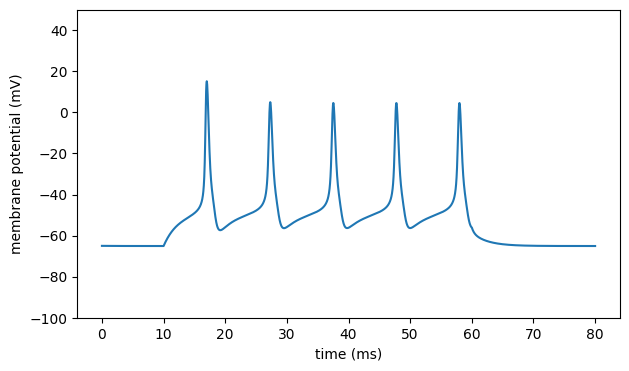

In [6]:
# baseline values matching reset_soma_pars() in the original my1stnrn.hoc:
# every conductance off, standard concentrations, no stimulus
DEFAULT_PARAMS = dict(
    pna_leak=0.0, pk_leak=0.0,
    gnabar_HH=0.069, gkbar_HH=0.0069,
    nai=31.0, nao=145.0, ki=135.0, ko=3.1,
    stim_delay=0.0, stim_dur=0.0, stim_amp=0.0,
    v_init=-65.0, tstop=20.0,# dt=0.05,
)

def run_experiment(**overrides):
    p = {**DEFAULT_PARAMS, **overrides}

    soma(0.5).pna_leak = p["pna_leak"]
    soma(0.5).pk_leak = p["pk_leak"]
    soma(0.5).gnabar_HH = p["gnabar_HH"]
    soma(0.5).gkbar_HH = p["gkbar_HH"]
    soma(0.5).nai = p["nai"]
    soma(0.5).nao = p["nao"]
    soma(0.5).ki = p["ki"]
    soma(0.5).ko = p["ko"]

    stim.delay = p["stim_delay"]
    stim.dur = p["stim_dur"]
    stim.amp = p["stim_amp"]

    h.tstop = p["tstop"]
    h.v_init = p["v_init"]
    # h.dt = p["dt"]
    h.run()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t_vec, v_vec)
    ax.set_xlabel("time (ms)")
    ax.set_ylabel("membrane potential (mV)")
    ax.set_ylim(-100, 50)
    plt.show()

# 1. Basic Experiments 1-6

Each entry only lists the values that differ from `DEFAULT_PARAMS`, mirroring how the original
`e*.par` files only set the parameters relevant to that experiment. In the original GUI's
"Basics" menu, each entry covers two textbook experiments (hence "1,2" etc. in the labels).
Sourced directly from `e1.par`, `e3.par` and `e5.par`.

In [14]:
# @title Specifying default parameters

EXPERIMENTS = {
    "1: Resting potential (exp. 1,2)": dict(
        pna_leak=2.07e-7, pk_leak=3.45e-6,
        gnabar_HH=0.0, gkbar_HH=0.0,
        nai=31, nao=145, ki=135, ko=3.1,
        v_init=-65, tstop=20,
    ),
    "2: Membrane properties (exp. 3,4)": dict(
        pna_leak=2.07e-7, pk_leak=3.45e-6,
        nai=31, nao=145, ki=135, ko=3.1,
        stim_delay=10, stim_dur=50, stim_amp=1.5,
        v_init=-65, tstop=80,
    ),
    "3: Impulse generation (exp. 5,6)": dict(
        pna_leak=2.07e-7, pk_leak=3.45e-6,
        nai=31, nao=145, ki=135, ko=3.1,
        stim_delay=10, stim_dur=50, stim_amp=2,
        v_init=-65, tstop=80,
    ),
}

from ipywidgets import FloatSlider, Checkbox, Button, Dropdown, HBox, VBox, Output, Layout, Label

# UI metadata (ranges/labels), wide enough to cover every experiment preset above.
# "scale" (default 1) lets a slider show nicer numbers than the raw NEURON value:
# browser range sliders handle small values like 1e-7 poorly, so pna_leak/pk_leak
# are shown as plain numbers and converted back to real units before running.
PARAM_UI = {
    "pna_leak": dict(min=0, max=8, step=0.01, readout_format=".2f", description="pNa (leak)", unit="\u00d710\u207b\u2077 cm/s", scale=1e-7),
    "pk_leak": dict(min=0, max=8, step=0.01, readout_format=".2f", description="pK (leak)", unit="\u00d710\u207b\u2076 cm/s", scale=1e-6),
    "gnabar_HH": dict(min=0, max=0.15, step=0.001, readout_format=".3f", description="gNa (HH)", unit="S/cm\u00b2"),
    "gkbar_HH": dict(min=0, max=0.02, step=0.0005, readout_format=".4f", description="gK (HH)", unit="S/cm\u00b2"),
    "nai": dict(min=0, max=60, step=1, description="nai", unit="mM"),
    "nao": dict(min=0, max=200, step=1, description="nao", unit="mM"),
    "ki": dict(min=0, max=200, step=1, description="ki", unit="mM"),
    "ko": dict(min=0, max=10, step=0.1, description="ko", unit="mM"),
    "stim_delay": dict(min=0, max=50, step=1, description="stim delay", unit="ms"),
    "stim_dur": dict(min=0, max=100, step=1, description="stim dur", unit="ms"),
    "stim_amp": dict(min=0, max=5, step=0.1, description="stim amp", unit="nA"),
    "v_init": dict(min=-90, max=-30, step=1, description="v_init", unit="mV"),
    "tstop": dict(min=5, max=200, step=5, description="tstop", unit="ms"),
    # "dt": dict(min=0.01, max=0.25, step=0.01, description="dt", unit="ms"),
}

def build_basicExp_dashboard():
    def _preset_for(exp_name):
        return {**DEFAULT_PARAMS, **EXPERIMENTS[exp_name]}

    def _display_value(name, raw_value):
        return raw_value / PARAM_UI[name].get("scale", 1)

    def _raw_value(name, display_value):
        return display_value * PARAM_UI[name].get("scale", 1)

    exp_selector = Dropdown(options=list(EXPERIMENTS.keys()), description="Experiment:",
                             style={"description_width": "initial"}, layout=Layout(width="320px"))
    current_defaults = _preset_for(exp_selector.value)

    sliders = {}
    changed_flags = {}
    rows = []

    def _make_change_handler(name):
        def _on_change(change):
            changed_flags[name].value = (change["new"] != _display_value(name, current_defaults[name]))
        return _on_change

    def _make_reset_handler(name):
        def _on_click(_btn):
            sliders[name].value = _display_value(name, current_defaults[name])
        return _on_click

    for name, spec in PARAM_UI.items():
        slider_kwargs = {k: v for k, v in spec.items() if k not in ("scale", "unit", "description")}
        slider = FloatSlider(value=_display_value(name, current_defaults[name]), description=spec["description"],
                              layout=Layout(width="350px"), **slider_kwargs)
        unit_label = Label(value=spec.get("unit", ""), layout=Layout(width="110px"))
        changed = Checkbox(value=False, description="changed", disabled=True, indent=False,
                            layout=Layout(width="90px"))
        reset_btn = Button(description="reset", layout=Layout(width="60px"))

        sliders[name] = slider
        changed_flags[name] = changed
        slider.observe(_make_change_handler(name), names="value")
        reset_btn.on_click(_make_reset_handler(name))

        rows.append(HBox([slider, unit_label, changed, reset_btn]))

    run_button = Button(description="Run", button_style="success", icon="play")
    reset_all_button = Button(description="Reset all", icon="undo")
    output = Output()

    def _on_run(_btn):
        with output:
            output.clear_output(wait=True)
            values = {name: _raw_value(name, slider.value) for name, slider in sliders.items()}
            run_experiment(**values)

    def _on_reset_all(_btn):
        for name, slider in sliders.items():
            slider.value = _display_value(name, current_defaults[name])

    def _on_experiment_change(change):
        nonlocal current_defaults
        current_defaults = _preset_for(change["new"])
        _on_reset_all(None)
        _on_run(None)

    run_button.on_click(_on_run)
    reset_all_button.on_click(_on_reset_all)
    exp_selector.observe(_on_experiment_change, names="value")

    dashboard = VBox([exp_selector, output, HBox([run_button, reset_all_button])] + rows)
    _on_run(None)  # show a default run immediately, without waiting for a click
    return dashboard


Pick an experiment from the dropdown to load its preset, then adjust sliders and click **Run**. Each parameter has a **reset** button to restore the current
experiment's value, and a **changed** checkbox that ticks itself whenever the value differs
from that preset.

In [16]:
from IPython.display import display
display(build_basicExp_dashboard())